# MACS30123 Lab Week 6

Author: Yangyu Wang (with reference to Jonathan Clindaniel)

Our job here is to use lambda function to calculate some NLP measures such as common words, sentence length and n-grams for the text file of anything you like from https://www.gutenberg.org/browse/scores/top.

We will go through creating S3, dynamoDB, and Lambda function once again by using boto3. The we will build SQS to trigger submision to databases through lambda function.

In [1]:
import boto3
import json
import uuid

## Set-up for S3, dynamoDB and lambda function

Let's first review on how to create S3, dynamoDB and submit lambda function through boto3.

#### S3

In [2]:
s3 = boto3.client('s3')

# TODO: change it to your own bucket name
s3_bucket_name = 'wangyd-nlp'

try:
    s3.create_bucket(Bucket=s3_bucket_name)
except s3.exceptions.BucketAlreadyOwnedByYou:
    print("Bucket already exists.")

Put raw data into S3

In [3]:
local_file = "animal_farm.txt" # or replace with any text file

!aws s3 cp "{local_file}" "s3://{s3_bucket_name}/"
!aws s3 ls "s3://{s3_bucket_name}/" | grep "animal_farm"

upload: ./animal_farm.txt to s3://wangyd-nlp/animal_farm.txt        
2026-04-30 21:57:00     169718 animal_farm.txt


#### DynamoDB

In [4]:
dynamodb = boto3.resource("dynamodb")
dynamodb_client = boto3.client('dynamodb')

# TODO: change it to your own bucket name
dynamodb_bucket_name = "wangyd-nlp" 

table = dynamodb.create_table(
    TableName=dynamodb_bucket_name,
    KeySchema=[
        {
            "AttributeName": "job_id",
            "KeyType": "HASH"
        }
    ],
    AttributeDefinitions=[
        {
            "AttributeName": "job_id",
            "AttributeType": "S"
        }
    ],
    ProvisionedThroughput={
        "ReadCapacityUnits": 1,
        "WriteCapacityUnits": 1
    }
)

table.meta.client.get_waiter("table_exists").wait(TableName=dynamodb_bucket_name)

print(table.item_count)
print(table.creation_date_time)

0
2026-04-30 21:57:00.120000-05:00


#### Lambda Function

In [5]:
aws_lambda = boto3.client('lambda')
iam_client = boto3.client('iam')
role = iam_client.get_role(RoleName='LabRole')

with open('lambda_function.zip', 'rb') as f:
    lambda_zip = f.read()

In [6]:
try:
    # If function hasn't yet been created, create it
    response = aws_lambda.create_function(
        FunctionName='NLPJobSubmission',
        Runtime='python3.10',
        Role=role['Role']['Arn'],
        Handler='lambda_function.lambda_handler',
        Timeout=120,
        Environment={
        'Variables': {
            'TABLE_NAME': 'wangyd-nlp'
                    }
        },
        Code=dict(ZipFile=lambda_zip)
    )
except aws_lambda.exceptions.ResourceConflictException:
    # If function already exists, update it based on zip
    # file contents
    response = aws_lambda.update_function_code(
        FunctionName='NLPJobSubmission',
        ZipFile=lambda_zip
        )

lambda_arn = response['FunctionArn']
lambda_arn

'arn:aws:lambda:us-east-1:267338668379:function:NLPJobSubmission'

Attach the layer to lambda function

In [7]:
# Publish a new layer version from layer.zip
with open("layer.zip", "rb") as f:
    layer_zip = f.read()

layer_response = aws_lambda.publish_layer_version(
    LayerName="NLPDependencies",
    Description="Third-party packages for NLPJobSubmission",
    Content={"ZipFile": layer_zip},
    CompatibleRuntimes=["python3.10"]
)

layer_arn = layer_response["LayerVersionArn"]
print("Published layer:", layer_arn)

# If function already exists, attach layer now
try:
    aws_lambda.update_function_configuration(
        FunctionName="NLPJobSubmission",
        Layers=[layer_arn]
    )
    print("Layer attached to NLPJobSubmission.")
except aws_lambda.exceptions.ResourceNotFoundException:
    print("Function not created yet. Use Layers=[layer_arn] in create_function.")

Published layer: arn:aws:lambda:us-east-1:267338668379:layer:NLPDependencies:7
Layer attached to NLPJobSubmission.


## Create SQS and Link it to Lambda

In [8]:
sqs = boto3.client('sqs')

visibility_timeout = 6 * 120 # 6 times the Lambda timeout to allow for retries

try:
    sqs_url = sqs.create_queue(
        QueueName='NLPJobsubmission',
        Attributes={
            'VisibilityTimeout': str(visibility_timeout)
        }
    )['QueueUrl']
except sqs.exceptions.QueueNameExists:
    sqs_url = [url
                 for url in sqs.list_queues()['QueueUrls']
                 if 'NLPJobsubmission' in url][0]
    
    sqs.set_queue_attributes(
        QueueUrl=sqs_url,
        Attributes={
            'VisibilityTimeout': str(visibility_timeout)
        }
    )
    
sqs_info = sqs.get_queue_attributes(QueueUrl=sqs_url,
                                    AttributeNames=['QueueArn'])
sqs_arn = sqs_info['Attributes']['QueueArn']

# Trigger Lambda Function when new messages enter SQS Queue
try:
    response = aws_lambda.create_event_source_mapping(
        EventSourceArn=sqs_arn,
        FunctionName='NLPJobSubmission',
        Enabled=True,
        BatchSize=10,
    )
except aws_lambda.exceptions.ResourceConflictException:
    es_id = aws_lambda.list_event_source_mappings(
        EventSourceArn=sqs_arn,
        FunctionName='NLPJobSubmission'
    )['EventSourceMappings'][0]['UUID']
    
    response = aws_lambda.update_event_source_mapping(
        UUID=es_id,
        FunctionName='NLPJobSubmission',
        Enabled=True,
        BatchSize=10
    )

In [9]:
print(sqs_url)

https://sqs.us-east-1.amazonaws.com/267338668379/NLPJobsubmission


## Send message to SQS to trigger the mission

In [10]:
queue_url = sqs_url
job_id = str(uuid.uuid4())  # a unique id for each analysis job
sqs = boto3.client('sqs')
message_body = {
    'job_id': job_id,
    'bucket': s3_bucket_name,
    'key': "animal_farm.txt"  # or replace it with any text file in your S3 bucket
}
response = sqs.send_message(
    QueueUrl=queue_url,
    MessageBody=json.dumps(message_body)
)
print(f"Message sent to SQS with job ID {job_id}\nand message ID {response['MessageId']}")

Message sent to SQS with job ID 802dd7f1-8c4f-4ec6-af7f-fae8619faccb
and message ID 3e46bf10-556b-4cfb-b99e-4c95e3b4317a


In [25]:
res = dynamodb_client.scan(TableName=dynamodb_bucket_name)
res

{'Items': [{'job_id': {'S': '802dd7f1-8c4f-4ec6-af7f-fae8619faccb'},
   'file_name': {'S': 'animal_farm.txt'},
   'result_file': {'S': 'results_animal_farm.txt'},
   'file_location': {'S': 'wangyd-nlp/animal_farm.txt'}}],
 'Count': 1,
 'ScannedCount': 1,
 'ResponseMetadata': {'RequestId': '4DB863M6SSAKPBM4S6IAGKDJN7VV4KQNSO5AEMVJF66Q9ASUAAJG',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'server': 'Server',
   'date': 'Fri, 01 May 2026 02:57:49 GMT',
   'content-type': 'application/x-amz-json-1.0',
   'content-length': '227',
   'connection': 'keep-alive',
   'x-amzn-requestid': '4DB863M6SSAKPBM4S6IAGKDJN7VV4KQNSO5AEMVJF66Q9ASUAAJG',
   'x-amz-crc32': '3320606018'},
  'RetryAttempts': 0}}

In [26]:
# Download the results file from S3
s3.download_file(s3_bucket_name, 'results_animal_farm.txt', 'results_animal_farm.txt')

with open('results_animal_farm.txt', 'r') as f:
    results = f.read()
    results_dict = json.loads(results)
    print(results_dict)

{'Vocabulary Size': 3747, 'Most Common Words': [['animals', 248], ['farm', 168], ['napoleon', 166], ['would', 138], ['snowball', 128], ['animal', 108], ['boxer', 95], ['pigs', 93], ['said', 93], ['jones', 80]], 'Sentence Length Variation': [173, 270, 72, 47, 100, 83, 461, 266, 114, 176, 108, 234, 146, 194, 109, 144, 160, 195, 120, 111, 214, 71, 67, 214, 53, 59, 202, 213, 128, 138, 131, 240, 105, 205, 35, 35, 160, 191, 45, 56, 62, 274, 86, 29, 69, 48, 106, 34, 161, 178, 52, 88, 51, 38, 35, 91, 58, 123, 34, 133, 116, 106, 84, 58, 115, 73, 116, 66, 132, 82, 60, 62, 34, 49, 121, 67, 49, 174, 124, 122, 68, 47, 21, 76, 47, 191, 78, 151, 59, 33, 144, 15, 55, 85, 20, 26, 45, 127, 124, 37, 59, 82, 26, 59, 98, 121, 45, 82, 40, 56, 81, 57, 144, 31, 64, 54, 42, 22, 65, 36, 64, 58, 154, 81, 52, 164, 40, 108, 34, 47, 141, 141, 129, 131, 129, 132, 133, 131, 71, 82, 192, 112, 106, 174, 111, 121, 89, 40, 119, 72, 47, 24, 60, 102, 212, 145, 117, 160, 146, 49, 139, 171, 64, 125, 145, 57, 154, 44, 83, 102

Please submit the results by SQS to 'https://sqs.us-east-1.amazonaws.com/267338668379/classsubmission', which will generate a wordcloud based on all submissions of the whole class (which I wrote in the similar way to what is in this notebook). You can visualize the wordcloud by getting the image back to your place. See how SQS could handle multiple request at the same time.

In [27]:
queue_url = 'https://sqs.us-east-1.amazonaws.com/267338668379/classsubmission'
job_id = str(uuid.uuid4())  # a unique id for each job
sqs = boto3.client('sqs')
message_body = {
    'job_id': job_id,
    'results': results_dict
}
response = sqs.send_message(
    QueueUrl=queue_url,
    MessageBody=json.dumps(message_body)
)
print(f"Message sent to SQS with job ID {job_id}\nand message ID {response['MessageId']}")

Message sent to SQS with job ID d9e6b2c7-8896-477d-82e1-55f2d2d8de46
and message ID 2164013f-f010-4e1e-9c49-d0ee2254ccae


Wordcloud found at s3://wangyd-class/wordclouds/combined_wordcloud.png


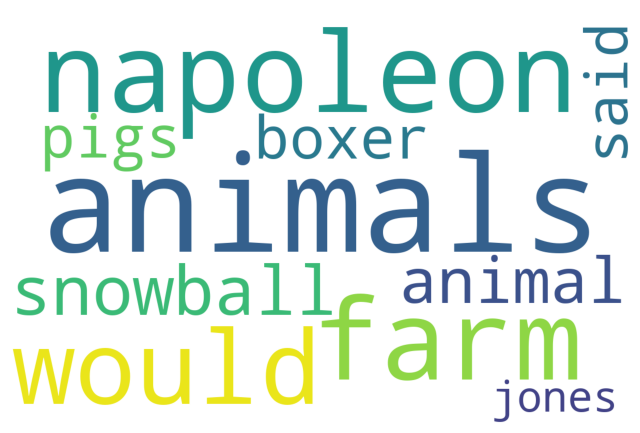

In [73]:
import io
from PIL import Image

import matplotlib.pyplot as plt

wordcloud_key = "wordclouds/combined_wordcloud.png"

s3_class = 'wangyd-class'
try:
    s3.head_object(Bucket=s3_class, Key=wordcloud_key)
    print(f"Wordcloud found at s3://{s3_class}/{wordcloud_key}")
    obj = s3.get_object(Bucket=s3_class, Key=wordcloud_key)
    img = Image.open(io.BytesIO(obj["Body"].read()))

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
except s3.exceptions.NoSuchKey:
    print(f"Wordcloud not found at s3://{s3_class}/{wordcloud_key}")
except Exception as e:
    print(f"Error checking for wordcloud: {e}")


## Clean up

In [28]:
sqs.delete_queue(QueueUrl=sqs_url)
print(f"SQS queue deleted: {sqs_url}")

SQS queue deleted: https://sqs.us-east-1.amazonaws.com/267338668379/NLPJobsubmission


In [29]:
aws_lambda = boto3.client('lambda')
aws_lambda.delete_function(FunctionName='NLPJobSubmission')

{'ResponseMetadata': {'RequestId': '74fceb2c-d498-4e7c-9303-54a7d294b5c4',
  'HTTPStatusCode': 204,
  'HTTPHeaders': {'date': 'Fri, 01 May 2026 02:59:10 GMT',
   'content-type': 'application/json',
   'connection': 'keep-alive',
   'x-amzn-requestid': '74fceb2c-d498-4e7c-9303-54a7d294b5c4'},
  'RetryAttempts': 0},
 'StatusCode': 204}

In [30]:
s3_resource = boto3.resource("s3")

def cleanup(bucket_name):
    bucket = s3_resource.Bucket(bucket_name)
    for item in bucket.objects.all():
        item.delete()
        
cleanup(s3_bucket_name)

In [31]:
table.delete()

{'TableDescription': {'TableName': 'wangyd-nlp',
  'TableStatus': 'DELETING',
  'ProvisionedThroughput': {'NumberOfDecreasesToday': 0,
   'ReadCapacityUnits': 1,
   'WriteCapacityUnits': 1},
  'TableSizeBytes': 0,
  'ItemCount': 0,
  'TableArn': 'arn:aws:dynamodb:us-east-1:267338668379:table/wangyd-nlp',
  'TableId': '744580cf-bf49-4b19-ad50-b421fceba97b',
  'DeletionProtectionEnabled': False},
 'ResponseMetadata': {'RequestId': 'B02C7H84UN9A699L1UEPAELSUFVV4KQNSO5AEMVJF66Q9ASUAAJG',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'server': 'Server',
   'date': 'Fri, 01 May 2026 02:59:13 GMT',
   'content-type': 'application/x-amz-json-1.0',
   'content-length': '356',
   'connection': 'keep-alive',
   'x-amzn-requestid': 'B02C7H84UN9A699L1UEPAELSUFVV4KQNSO5AEMVJF66Q9ASUAAJG',
   'x-amz-crc32': '3830736687'},
  'RetryAttempts': 0}}